In [1]:
import os
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
import librosa.display
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, callbacks, losses
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [2]:
def create_mfcc(segmented_dir, n_mfcc=13, hop_length=512):
    segmented_dir = Path(segmented_dir)
    X = []
    y = []
    labels = [f.name for f in segmented_dir.iterdir() if f.is_dir()]

    for label in tqdm(labels):
        for audio in (segmented_dir / label).iterdir():
            if audio.suffix == ".wav":
                signal, sr = librosa.load(audio, sr=None)
                n_fft = min(2048, len(signal))
                mfcc = librosa.feature.mfcc(y=signal, 
                                            sr=sr, 
                                            n_mfcc=n_mfcc, 
                                            n_fft=n_fft, 
                                            hop_length=hop_length)
                X.append(mfcc)
                y.append(label)

    X = np.array(X)
    X = np.expand_dims(X, axis=-1)

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

    return X, np.array(y), label_encoder

Import data for model

In [3]:
X, y, label_encoder = create_mfcc('IRMAS_segmented')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=1)

100%|██████████| 11/11 [11:17<00:00, 61.58s/it]


Plot MFCC

In [4]:
def plot_mfcc(X, i=0):
    mfcc_sample = X[i, :, :, 0]
    librosa.display.specshow(mfcc_sample, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('MFCC')
    plt.xlabel('Time Frames')
    plt.ylabel('MFCC Coefficients')
    plt.show()

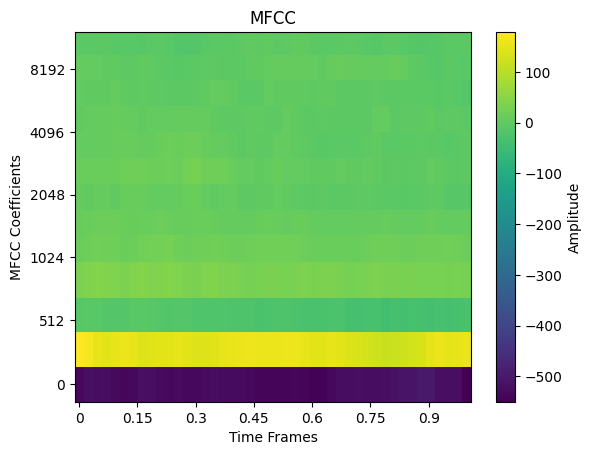

In [5]:
plot_mfcc(X)

CNN model

In [6]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(X.shape[1], X.shape[2], 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.4),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(np.unique(y)), activation='softmax')
])

cnn.compile(optimizer='adam',
            loss=losses.SparseCategoricalCrossentropy(),
            metrics=['accuracy'])

c:\Users\grzes\anaconda3\envs\audio\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train CNN

In [7]:
early_stopping = callbacks.EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)

history = cnn.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[early_stopping], class_weight=class_weights_dict)

Epoch 1/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.2198 - loss: 2.2398 - val_accuracy: 0.3650 - val_loss: 1.8633
Epoch 2/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.3398 - loss: 1.9585 - val_accuracy: 0.3936 - val_loss: 1.7826
Epoch 3/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.3774 - loss: 1.8628 - val_accuracy: 0.4272 - val_loss: 1.7325
Epoch 4/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.4113 - loss: 1.7852 - val_accuracy: 0.4564 - val_loss: 1.6256
Epoch 5/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.4173 - loss: 1.7356 - val_accuracy: 0.4557 - val_loss: 1.6075
Epoch 6/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.4307 - loss: 1.7127 - val_accuracy: 0.4619 - val_loss: 1.6239
Epoch 7/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.4461 - loss: 1.6681 - val_accuracy: 0.4949 - val_loss: 1.5354
Epoch 8/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.4601 - loss: 1

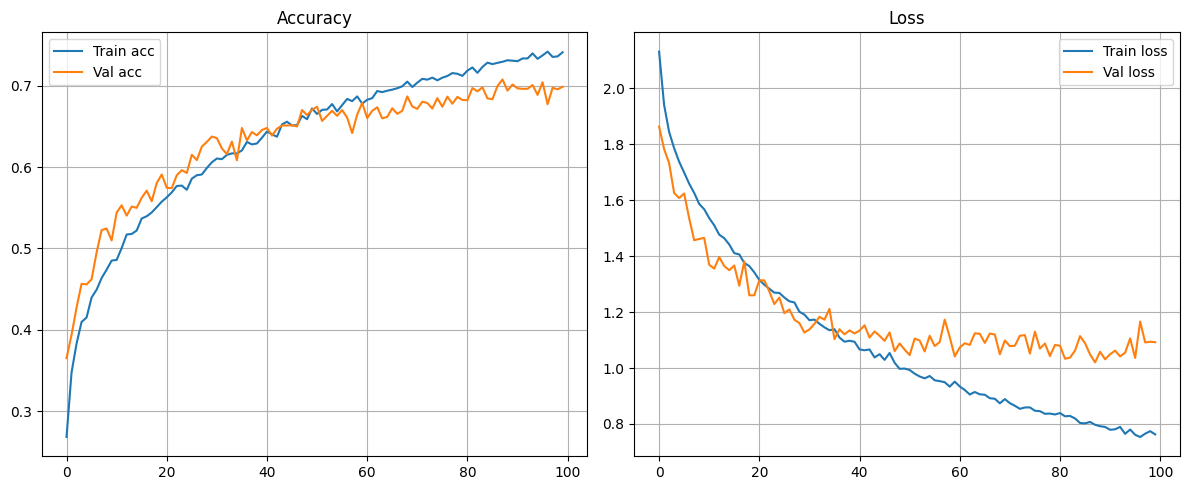

In [ ]:
# with open("IRMAS_cnn_mfcc_history.pkl", "wb") as f:
#     pickle.dump(history.history, f)
    
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train acc')
plt.plot(history.history['val_accuracy'], label='Val acc')
plt.title('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
# plt.savefig("IRMAS_cnn_mfcc_training_curves.png")
plt.show()

Evaluate CNN

In [ ]:
y_pred = cnn.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test)

accuracy = accuracy_score(y_test_labels, y_pred_labels)
class_report = classification_report(y_test_labels, y_pred_labels)

print('Accuracy:', accuracy)
print('\nClassification Report:\n', class_report)

# output_file = 'cnn_mfcc_evaluation.txt'

# with open(output_file, 'w') as file:
#     file.write(f'Accuracy: {accuracy}\n')
#     file.write('\nClassification Report:\n')
#     file.write(class_report)

# best .69

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.6910265970668655

Classification Report:
               precision    recall  f1-score   support

         cel       0.63      0.83      0.72       233
         cla       0.63      0.70      0.66       303
         flu       0.55      0.56      0.56       270
         gac       0.74      0.80      0.77       382
         gel       0.73      0.66      0.69       456
         org       0.74      0.76      0.75       409
         pia       0.77      0.59      0.67       433
         sax       0.57      0.60      0.58       376
         tru       0.73      0.66      0.70       346
         vio       0.64      0.68      0.66       348
         voi       0.80      0.77      0.79       467

    accuracy                           0.69      4023
   macro avg       0.68      0.69      0.69      4023
weighted avg       0.70      0.69      0.69      4023



Save CNN

In [10]:
# cnn.save('cnn_mfcc_model.h5')